In [80]:
from sklearn.model_selection import ParameterGrid
import random
import simpy
import numpy as np
import matplotlib.pyplot as plt

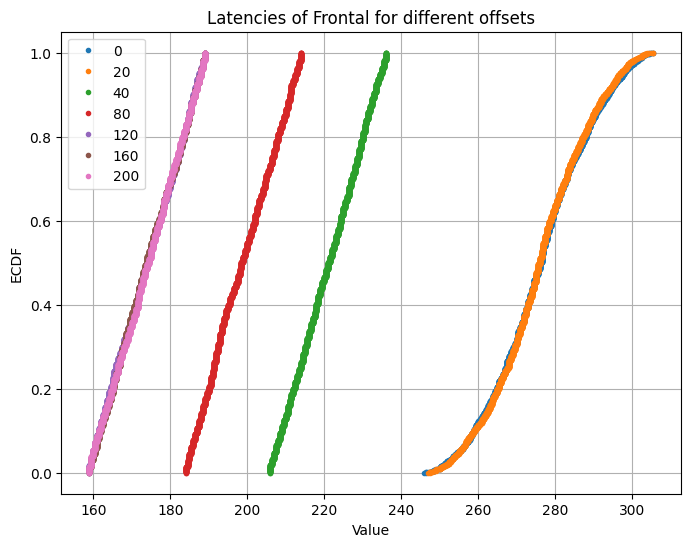

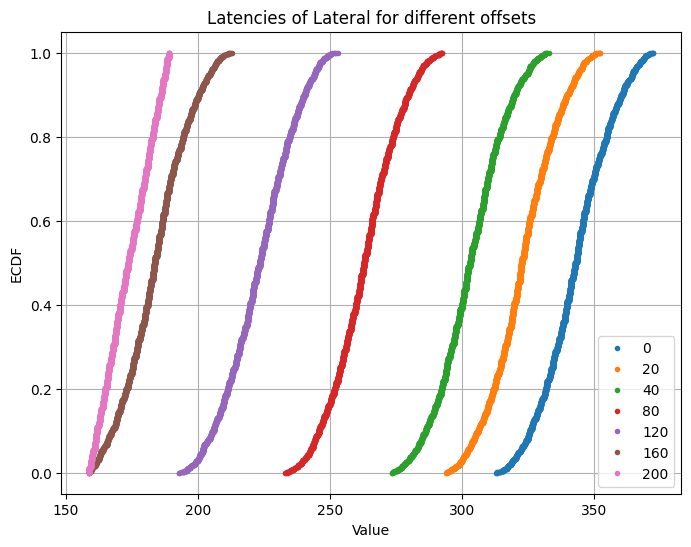

In [96]:
NUM_IMAGES_SIMULATED=2500

def image_processing_service(env,offset,name,resources,num_images):
    yield env.timeout(offset)
    for img_nr in range(num_images):
        env.process(image_processing(env,img_nr,name,resources))
        yield env.timeout(400)      

def image_processing(env,number,name,resources):
    #print(f"Starting to process {name} image {number} at {env.now}")
    latency_start = env.now
    
    with resources["cpu"].request() as res:
        yield res
        image_pre_processing_load = 50
        yield env.timeout(image_pre_processing_load / resources["cpu_rate"] )
    
    with resources["cpu"].request() as res:
        yield res
        motion_compensation_load = 44
        yield env.timeout(motion_compensation_load / resources["cpu_rate"] )

    with resources["cpu"].request() as res:
        yield res
        noise_reduction_load = random.randint(80,140)
        yield env.timeout(noise_reduction_load / resources["cpu_rate"] )
    
    with resources["cpu"].request() as res:
        yield res
        contrast_load = 134
        yield env.timeout(contrast_load / resources["cpu_rate"] )

    with resources["gpu"].request() as res:
        yield res
        image_post_processing_load = 25
        yield env.timeout(image_post_processing_load / resources["gpu_rate"] )
    
    #print(f"Ending processing {name} image {number} at {env.now}")
    latency_end = env.now
    
    if name=="Frontal":
        latencies_frontal_exp.append(latency_end-latency_start)
    else:
        latencies_lateral_exp.append(latency_end-latency_start)

latencies_frontal = {}
latencies_lateral = {}

latencies_frontal_exp=[]
latencies_lateral_exp=[]

param_grid = { "offset": [0, 20, 40, 80, 120, 160, 200] }
design_space = ParameterGrid(param_grid)

for params in design_space:
    env = simpy.Environment()
    resources = {"cpu": simpy.Resource(env,1), "cpu_rate":2, "gpu": simpy.Resource(env,1), "gpu_rate":5}    
    env.process(image_processing_service(env,0,"Frontal",resources,NUM_IMAGES_SIMULATED))
    env.process(image_processing_service(env,params["offset"],"Lateral",resources,NUM_IMAGES_SIMULATED))
    env.run()

    latencies_frontal[str(params)] = latencies_frontal_exp
    latencies_lateral[str(params)] = latencies_lateral_exp
    
    latencies_frontal_exp,latencies_lateral_exp=[],[]

for params in design_space:
    print("")
    #print(str(params))
    #print(np.mean(latencies_frontal[str(params)]))
    #print(np.mean(latencies_lateral[str(params)]))

plt.figure(figsize=(8, 6))
plt.xlabel('Value')
plt.ylabel('ECDF')
plt.title('Latencies of Frontal for different offsets')
plt.grid(True)

# Compute ECDF
for params in design_space:
    x = latencies_frontal[str(params)]
    x_sorted = np.sort(x)
    y = np.arange(1, len(x_sorted) + 1) / len(x_sorted)
    plt.plot(x_sorted, y, marker='.', linestyle='none', label=params["offset"])

# Plot ECDF
plt.legend()
plt.show()


plt.figure(figsize=(8, 6))
plt.xlabel('Value')
plt.ylabel('ECDF')
plt.title('Latencies of Lateral for different offsets')
plt.grid(True)

# Compute ECDF
for params in design_space:
    x = latencies_lateral[str(params)]
    x_sorted = np.sort(x)
    y = np.arange(1, len(x_sorted) + 1) / len(x_sorted)
    plt.plot(x_sorted, y, marker='.', linestyle='none', label=params["offset"])

# Plot ECDF
plt.legend()
plt.show()